In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from ant.market import Market, BaseAgent
from ant.decentralised.direct import ProportionalAgent, EqualDivisionAgent, OptimalAgent
from ant.centralised import P4

In [2]:
# Demo experiment
market_size = 100
seed = 7
G = nx.gnp_random_graph(market_size, 0.2)
M1: Market = Market(market_size, graph=G, seed=seed)
M2: Market = Market(market_size, graph=G, seed=seed, agent_type=ProportionalAgent)
M3: Market = Market(market_size, graph=G, seed=seed, agent_type=EqualDivisionAgent)
M4: Market = Market(market_size, graph=G, seed=seed, agent_type=OptimalAgent)

# nx.draw(M1.graph)

In [3]:
allocation_matrix, utility = computed_equilibrium = P4(M1)

optimal_agents: List[OptimalAgent] = M4.agents
for agent in optimal_agents:
    agent.set_allocation_matrix(allocation_matrix)

In [8]:
simulation_length = 400
M1.set_market_equilibrium(allocation_matrix, utility)
M2.set_market_equilibrium(allocation_matrix, utility)
M3.set_market_equilibrium(allocation_matrix, utility)
M4.set_market_equilibrium(allocation_matrix, utility)
simulated_state_base = M1.simulate(simulation_length)
simulated_state_prop = M2.simulate(simulation_length)
simulated_state_equal = M3.simulate(simulation_length)
simulated_state_optimal = M4.simulate(simulation_length)

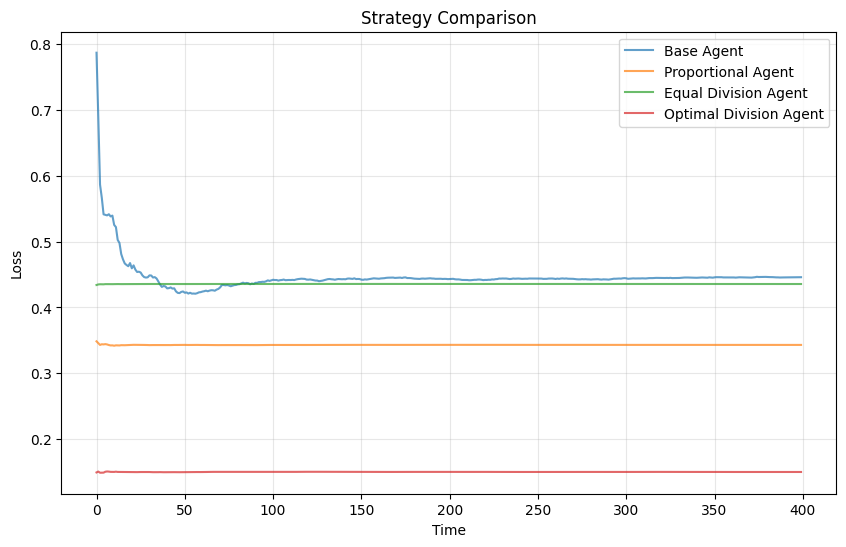

In [10]:
time_steps = np.arange(simulation_length)

plt.figure(figsize=(10, 6))
plt.plot(time_steps, simulated_state_base, label="Base Agent", alpha=0.7)
plt.plot(time_steps, simulated_state_prop, label="Proportional Agent", alpha=0.7)
plt.plot(time_steps, simulated_state_equal, label="Equal Division Agent", alpha=0.7)
plt.plot(time_steps, simulated_state_optimal, label="Optimal Division Agent", alpha=0.7)
# plt.axhline(y=utility, color='red', linestyle='--', linewidth=2, label='Equilibrium')

plt.xlabel("Time")
plt.ylabel("Loss")
plt.title("Strategy Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
allocation_matrix

x = np.array([[1, 2], [3, 4]])
print(x[1], np.sum(x, axis=1))

[3 4] [3 7]
